In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pygments.lexer import include


In [2]:
df = pd.read_csv('StudentSocialMediaAndMentalHealthImpact.csv')

In [3]:
df.shape


(5000, 13)

In [4]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [5]:
df.isnull().sum()


Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(2)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [8]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# EDA{Exploratory Data Analysis}



<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

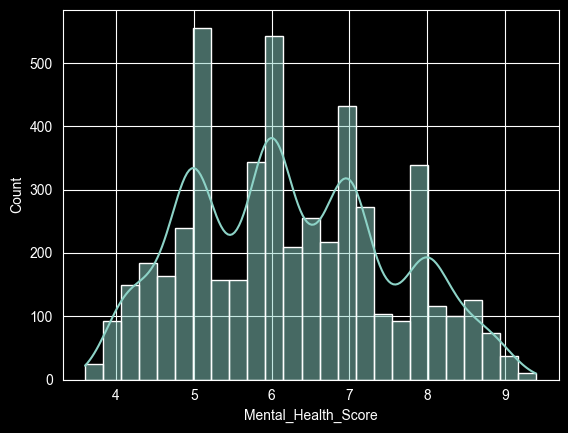

In [9]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

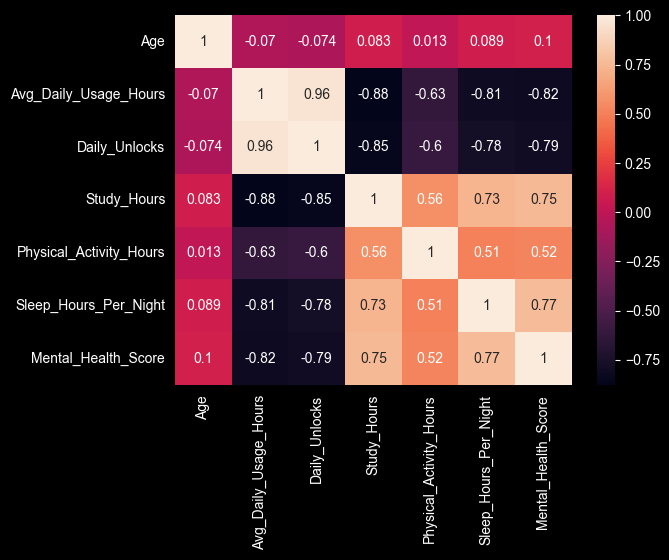

In [10]:
 sns.heatmap(df.corr(numeric_only=True),annot=True)

In [11]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

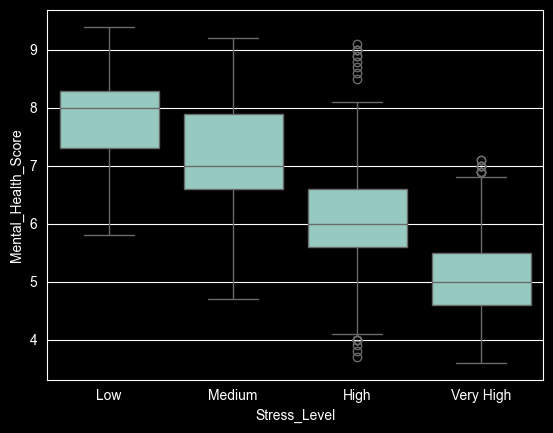

In [12]:
order=['Low','Medium','High','Very High']

sns.boxplot(data= df , x= 'Stress_Level', y= 'Mental_Health_Score', order=order)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

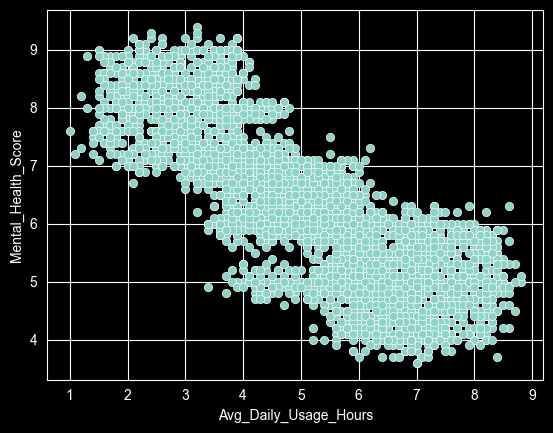

In [13]:
sns.scatterplot(x='Avg_Daily_Usage_Hours' ,y='Mental_Health_Score',data=df )

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

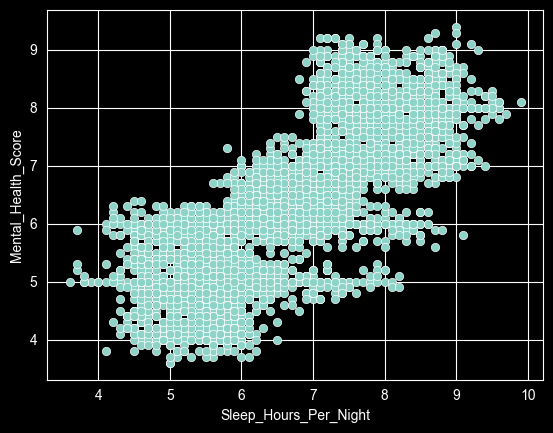

In [14]:
sns.scatterplot(data=df,x='Sleep_Hours_Per_Night',y='Mental_Health_Score')

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

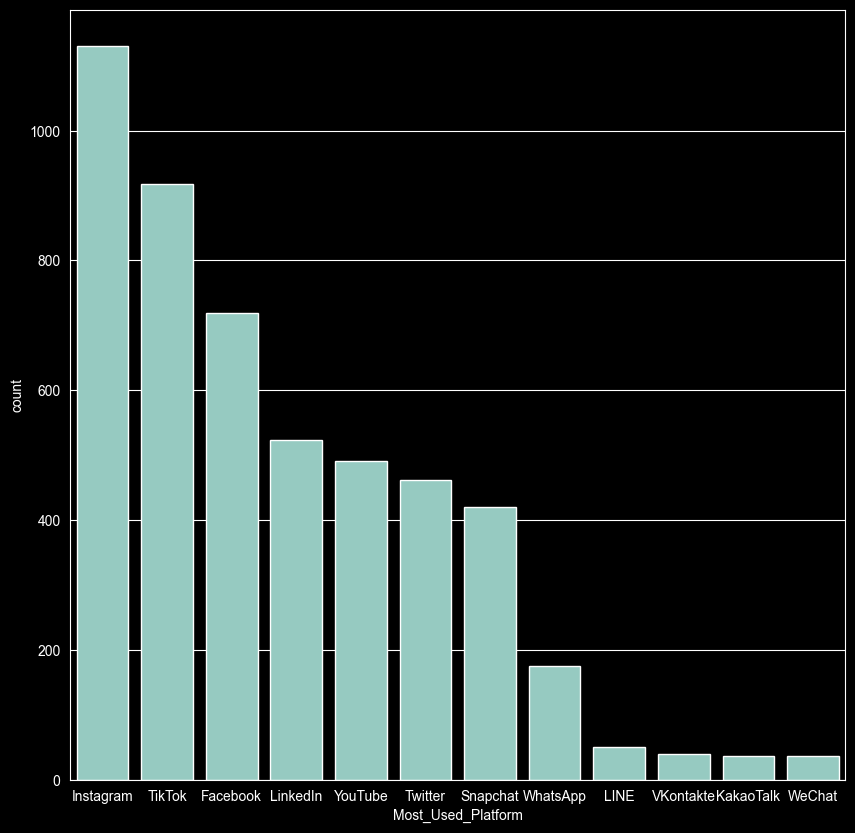

In [15]:
plt.figure(figsize=(10,10))
sns.countplot(data=df,x=df['Most_Used_Platform'],order=df['Most_Used_Platform'].value_counts().index)

# checking Outliers


In [16]:
num_features= df.select_dtypes(include = 'number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1-1.5*IQR
upper_bound = Q3+1.5*IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)

print(outliers.sum())

Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# Data Cleaning

In [17]:
df.drop_duplicates(inplace=True)

In [18]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0)

In [19]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


# checking skewness


In [20]:
num_col= df.select_dtypes(include = 'number')
num_col

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
0,21,4.0,134,4.5,2.2,6.7,6.8
1,23,1.6,73,7.0,2.4,8.6,7.6
2,22,4.6,166,4.0,1.8,6.7,7.0
3,18,7.0,220,1.0,1.7,5.4,5.3
4,24,7.5,237,1.0,1.1,5.0,4.4
...,...,...,...,...,...,...,...
4995,18,1.9,89,6.1,2.2,7.9,7.9
4996,18,6.6,216,2.3,1.8,6.0,4.7
4997,19,3.8,151,5.4,1.4,7.5,7.0
4998,18,3.8,119,4.0,1.5,6.4,6.7


In [21]:
num_col.skew()
# if value near to zero -> centralized
#value -ve -> left skew
#value +vve -> right skew

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

In [22]:
top_countries = df['Country'].value_counts().index[:10].to_list()
top_countries

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France']

In [23]:
def countries(Country):
    if Country in top_countries:
        return Country
    else:
        return 'other'

In [24]:
df['grouped_country'] = df['Country'].apply(countries)

In [25]:
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,grouped_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [26]:
df['grouped_country'].value_counts()

grouped_country
Other        1879
other        1352
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

In [27]:
from sklearn.model_selection import train_test_split
skewed_col = ['Study_Hours']

other_numeric_cols = [
    "Age", "Avg_Daily_Usage_Hours", "Daily_Unlocks",
    "Physical_Activity_Hours", "Sleep_Hours_Per_Night"
]

ordinal_col = ['Stress_Level']

normal_col = [
    "Gender", "Academic_Level", "Most_Used_Platform",
    "Purpose_Of_Use", "grouped_country"]
feature_col = skewed_col + other_numeric_cols + ordinal_col + normal_col
x=df[feature_col]

y = df['Mental_Health_Score']

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.30,random_state=42)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder,OneHotEncoder

# skewed Feature
skew_pipeline = Pipeline(steps=[('log_transform',FunctionTransformer(np.log1p)),('scale',StandardScaler())])
#numeric Feature
plain_numeric_pipeline = Pipeline(steps=[('scale',StandardScaler())])
#Ordinal
ordinal_numeric_pipeline = Pipeline(steps=[('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))])

#Nominal
Nominal_pipeline = Pipeline(steps=[('encode',OneHotEncoder(handle_unknown='ignore'))])

In [29]:
from sklearn.compose import ColumnTransformer
# (konsi pipeline , konsa column)
preprocessor= ColumnTransformer(transformers=[
    ('skewed_pipeline',skew_pipeline,skewed_col),
    ('plain_numeric',plain_numeric_pipeline,other_numeric_cols),
    ('ordinal_numeric',ordinal_numeric_pipeline,ordinal_col),
    ('nominal_pipeline',Nominal_pipeline,normal_col),
])

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
lr_pipeline = Pipeline(steps=[('preprocessor',preprocessor),('regressor',LinearRegression())])

lr_pipeline.fit(X_train,y_train)

lr_pred = lr_pipeline.predict(X_test)
lr_pred_train = lr_pipeline.predict(X_train)

lr_r2_test = r2_score(y_test,lr_pred)
lr_r2_train = r2_score(y_train,lr_pred_train)
lr_mae = mean_absolute_error(y_test,lr_pred)


print(f"r2 score for training data: {lr_r2_train}")
print(f"r2 score for test data: {lr_r2_test}")
print(f"mean_absolute_error for training data: {lr_mae}")

r2 score for training data: 0.7318991298307536
r2 score for test data: 0.7446750207322383
mean_absolute_error for training data: 0.5364273713851445


In [31]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('regressor',RandomForestRegressor(random_state=42))
])
rf_pipeline.fit(X_train,y_train)
rf_pred = rf_pipeline.predict(X_test)
rf_pred_train = rf_pipeline.predict(X_train)

rf_r2_score = r2_score(y_test,rf_pred)
rf_r2_score_train = r2_score(y_train,rf_pred_train)
rf_mae= mean_absolute_error(y_test,rf_pred)
print(f"r2 score for training data: {rf_r2_score_train}")
print(f"r2 score for test data: {rf_r2_score}")
print(f"mean_absolute_error for training data: {rf_mae}")

r2 score for training data: 0.9820717724358264
r2 score for test data: 0.8903716561430134
mean_absolute_error for training data: 0.3256867333333336


In [32]:
# hyperparametre tunning
from sklearn.model_selection import RandomizedSearchCV
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [5, 10, 15],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    n_jobs=1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)


Fitting 5 folds for each of 15 candidates, totalling 75 fits


,estimator,Pipeline(step...m_state=42))])
,param_distributions,"{'regressor__max_depth': [5, 10, ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], 'regressor__n_estimators': [100, 200, ...]}"
,n_iter,15
,scoring,'r2'
,n_jobs,1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [33]:
random_search.best_params_

{'regressor__n_estimators': 300,
 'regressor__min_samples_split': 5,
 'regressor__min_samples_leaf': 2,
 'regressor__max_depth': 15}

In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_best_pipeline = random_search.best_estimator_

rf_train_preds = rf_best_pipeline.predict(X_train)

print(f"R² score for training data: {r2_score(y_train, rf_train_preds):.4f}")
print(f"MAE for training data: {mean_absolute_error(y_train, rf_train_preds):.4f}")
print(f"RMSE for training data: {np.sqrt(mean_squared_error(y_train, rf_train_preds)):.4f}")

R² score for training data: 0.9583
MAE for training data: 0.1895
RMSE for training data: 0.2569


In [35]:
import joblib
joblib.dump(rf_pipeline,'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

In [44]:
df.columns.tolist()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'grouped_country']

In [49]:
df['Academic_Level'].unique()

array(['Undergraduate', 'Graduate', 'High School'], dtype=object)

In [52]:
df['Most_Used_Platform'].unique()

array(['Facebook', 'LinkedIn', 'Instagram', 'Snapchat', 'Twitter',
       'YouTube', 'TikTok', 'LINE', 'KakaoTalk', 'VKontakte', 'WhatsApp',
       'WeChat'], dtype=object)

In [54]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)